In [ ]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, LayerNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt


load dataset

In [ ]:
from google.colab import files
import zipfile
import pandas as pd

# Upload ZIP
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

# Extract ZIP
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall("kaggle_data")

# Load CSV yang benar
sales = pd.read_csv("kaggle_data/sales_train.csv")

print("Dataset loaded successfully!")
sales.head()


Saving competitive-data-science-predict-future-sales.zip to competitive-data-science-predict-future-sales.zip
Dataset loaded successfully!


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0


In [ ]:
print(sales.head())
print(sales.info())


         date  date_block_num  shop_id  item_id  item_price  item_cnt_day
0  02.01.2013               0       59    22154      999.00           1.0
1  03.01.2013               0       25     2552      899.00           1.0
2  05.01.2013               0       25     2552      899.00          -1.0
3  06.01.2013               0       25     2554     1709.05           1.0
4  15.01.2013               0       25     2555     1099.00           1.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   date            object 
 1   date_block_num  int64  
 2   shop_id         int64  
 3   item_id         int64  
 4   item_price      float64
 5   item_cnt_day    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 134.4+ MB
None


KONVERSI KE BULANAN (TIME-SERIES VALID)

In [ ]:
sales['date'] = pd.to_datetime(sales['date'], format='%d.%m.%Y')
sales['year_month'] = sales['date'].dt.to_period('M')


In [ ]:
monthly_sales = (
    sales
    .groupby(['shop_id', 'year_month'])['item_cnt_day']
    .sum()
    .reset_index()
    .rename(columns={'item_cnt_day': 'sales'})
)


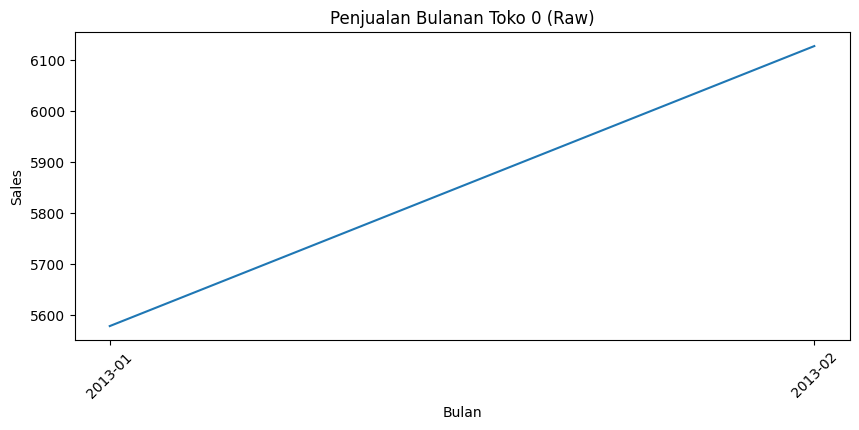

In [ ]:
sample_shop = monthly_sales['shop_id'].iloc[0]
sample_data = monthly_sales[monthly_sales['shop_id'] == sample_shop]

plt.figure(figsize=(10,4))
plt.plot(sample_data['year_month'].astype(str), sample_data['sales'])
plt.xticks(rotation=45)
plt.title(f"Penjualan Bulanan Toko {sample_shop} (Raw)")
plt.xlabel("Bulan")
plt.ylabel("Sales")
plt.show()


NORMALISASI DATA

In [ ]:
scaler = MinMaxScaler()
monthly_sales['sales_scaled'] = scaler.fit_transform(
    monthly_sales[['sales']]
)


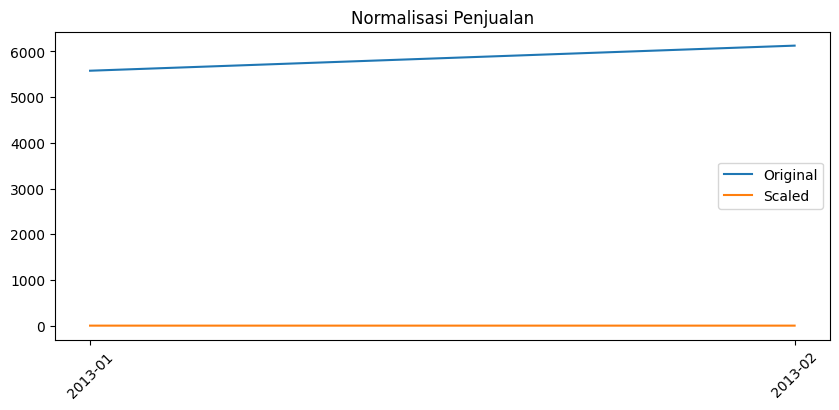

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(sample_data['year_month'].astype(str),
         sample_data['sales'], label='Original')
plt.plot(sample_data['year_month'].astype(str),
         monthly_sales[monthly_sales['shop_id'] == sample_shop]['sales_scaled'],
         label='Scaled')
plt.xticks(rotation=45)
plt.title("Normalisasi Penjualan")
plt.legend()
plt.show()


WINDOWING TIME SERIES (t → t+1)

In [ ]:
def create_window(series, window_size=12):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)


In [ ]:
WINDOW = 12
X_all, y_all = [], []

for shop_id, g in monthly_sales.groupby('shop_id'):
    series = g.sort_values('year_month')['sales_scaled'].values
    if len(series) > WINDOW:
        X, y = create_window(series, WINDOW)
        X_all.append(X)
        y_all.append(y)

X_all = np.concatenate(X_all)
y_all = np.concatenate(y_all)

X_all = X_all.reshape(-1, WINDOW, 1)


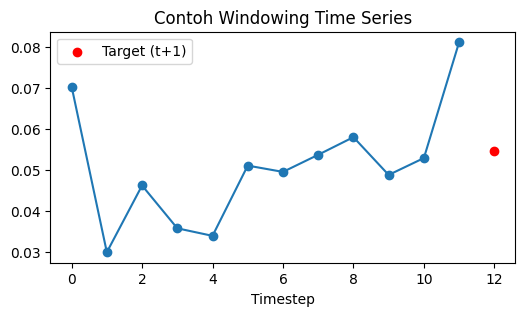

In [ ]:
idx = 0

plt.figure(figsize=(6,3))
plt.plot(range(WINDOW), X_all[idx].flatten(), marker='o')
plt.scatter(WINDOW, y_all[idx], color='red', label='Target (t+1)')
plt.title("Contoh Windowing Time Series")
plt.xlabel("Timestep")
plt.legend()
plt.show()


TRAIN–VALIDATION SPLIT (TIME-AWARE)

In [ ]:
split = int(0.8 * len(X_all))

X_train, X_val = X_all[:split], X_all[split:]
y_train, y_val = y_all[:split], y_all[split:]


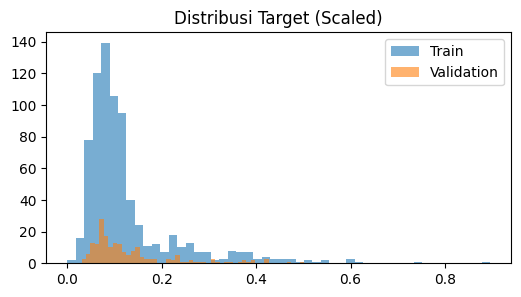

In [ ]:
plt.figure(figsize=(6,3))
plt.hist(y_train, bins=50, alpha=0.6, label='Train')
plt.hist(y_val, bins=50, alpha=0.6, label='Validation')
plt.title("Distribusi Target (Scaled)")
plt.legend()
plt.show()


ARSITEKTUR MODEL GRU

In [ ]:
def build_gru_model(timesteps, features, l2_value=None, dropout_rate=None):
    inputs = Input(shape=(timesteps, features))

    x = GRU(
        64,
        return_sequences=False,
        kernel_regularizer=regularizers.l2(l2_value) if l2_value else None
    )(inputs)

    x = LayerNormalization()(x)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)

    x = Dense(64, activation='relu')(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
        loss='mse',
        metrics=['mae']
    )

    return model


EKSPERIMEN REGULARISASI

In [ ]:
experiments = {
    "no_reg": {"l2": None, "dropout": None},
    "l2_0.01": {"l2": 0.01, "dropout": None},
    "l2_0.1": {"l2": 0.1, "dropout": None},
    "dropout_0.2": {"l2": None, "dropout": 0.2},
    "dropout_0.5": {"l2": None, "dropout": 0.5},
    "dropout_0.7": {"l2": None, "dropout": 0.7},
}


TRAINING LOOP + VISUALISASI LOSS


Training model: no_reg
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


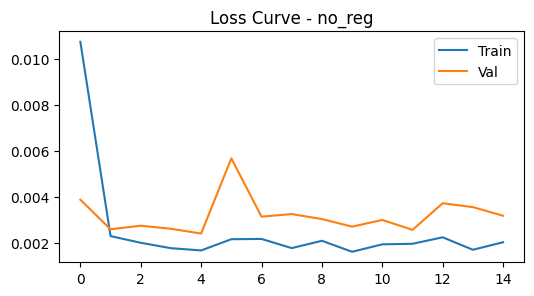

MAE : 0.0287
RMSE: 0.0491

Training model: l2_0.01
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


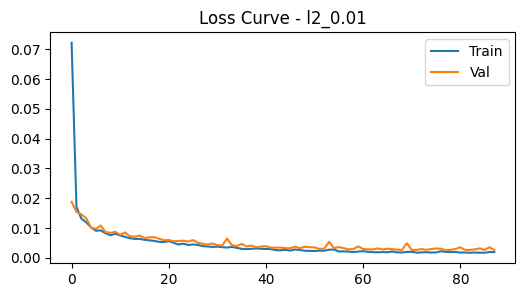

MAE : 0.0257
RMSE: 0.0480

Training model: l2_0.1


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


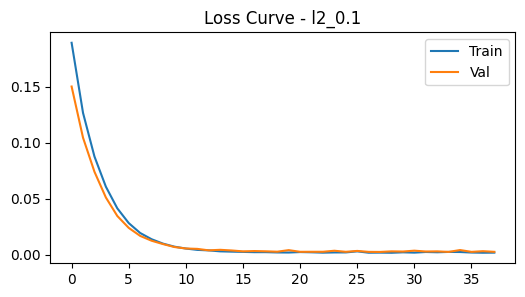

MAE : 0.0250
RMSE: 0.0487

Training model: dropout_0.2


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


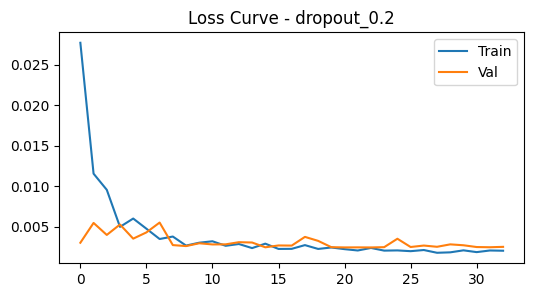

MAE : 0.0279
RMSE: 0.0494

Training model: dropout_0.5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


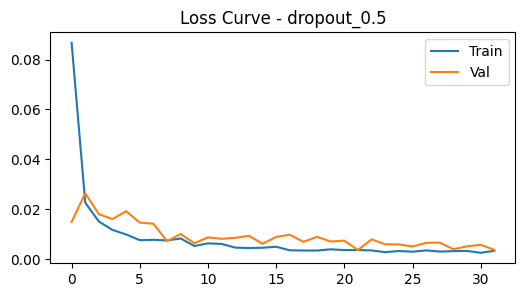

MAE : 0.0357
RMSE: 0.0606

Training model: dropout_0.7
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


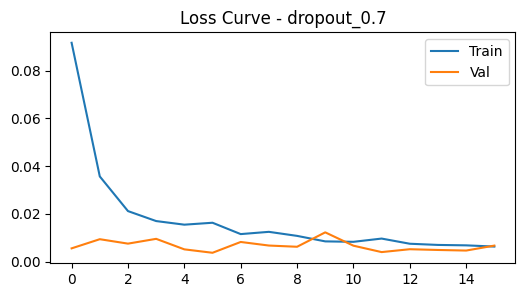

MAE : 0.0360
RMSE: 0.0605


In [ ]:
results = {}

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

for name, cfg in experiments.items():
    print(f"\nTraining model: {name}")

    model = build_gru_model(
        timesteps=WINDOW,
        features=1,
        l2_value=cfg["l2"],
        dropout_rate=cfg["dropout"]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    results[name] = {
        "model": model,
        "history": history,
        "MAE": mae,
        "RMSE": rmse
    }

    # LOSS CURVE
    plt.figure(figsize=(6,3))
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f"Loss Curve - {name}")
    plt.legend()
    plt.show()

    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")


PERBANDINGAN MODEL (BISNIS-ORIENTED)

In [ ]:
summary = pd.DataFrame({
    k: {"MAE": v["MAE"], "RMSE": v["RMSE"]}
    for k, v in results.items()
}).T

summary = summary.sort_values("RMSE")

print(summary)

                  MAE      RMSE
l2_0.01      0.025656  0.048014
l2_0.1       0.025009  0.048744
no_reg       0.028655  0.049109
dropout_0.2  0.027908  0.049381
dropout_0.7  0.035973  0.060487
dropout_0.5  0.035706  0.060624


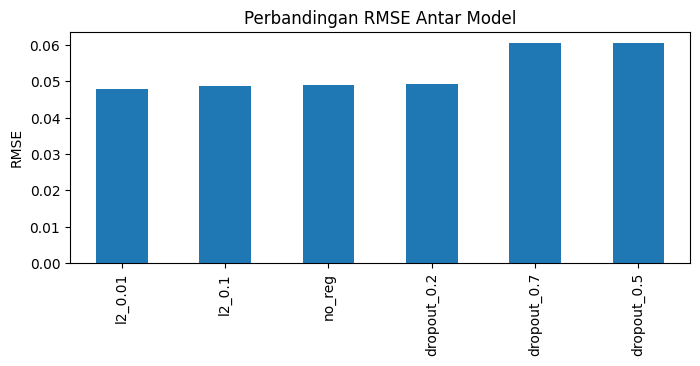

In [ ]:
summary['RMSE'].plot(kind='bar', figsize=(8,3))
plt.title("Perbandingan RMSE Antar Model")
plt.ylabel("RMSE")
plt.show()


PREDIKSI vs AKTUAL (MODEL TERBAIK)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


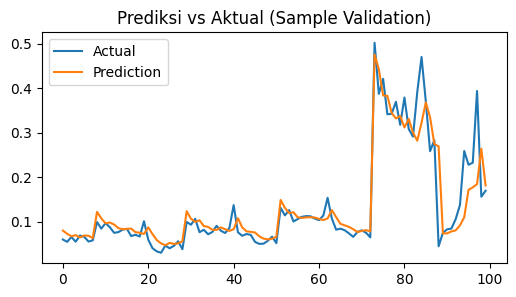

In [ ]:
best_model_name = summary.index[0]
best_model = results[best_model_name]['model']

val_pred = best_model.predict(X_val)

plt.figure(figsize=(6,3))
plt.plot(y_val[:100], label='Actual')
plt.plot(val_pred[:100], label='Prediction')
plt.title("Prediksi vs Aktual (Sample Validation)")
plt.legend()
plt.show()


PREDIKSI BULAN DEPAN (t+1)

In [ ]:
last_window = X_all[-1].reshape(1, WINDOW, 1)
pred_scaled = best_model.predict(last_window)
pred_sales = scaler.inverse_transform(pred_scaled)

print("Prediksi penjualan bulan depan:", pred_sales[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Prediksi penjualan bulan depan: 1050.1832


In [ ]:
shop_id = 2

shop_data = (
    monthly_sales[monthly_sales['shop_id'] == shop_id]
    .sort_values('year_month')
)

series = shop_data['sales_scaled'].values

if len(series) < WINDOW:
    print(f"Toko {shop_id} tidak punya data cukup untuk prediksi.")
else:
    last_window = series[-WINDOW:].reshape(1, WINDOW, 1)
    pred_scaled = best_model.predict(last_window)
    pred_sales = scaler.inverse_transform(pred_scaled)

    print(f"Prediksi penjualan bulan depan toko {shop_id}:",
          pred_sales[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Prediksi penjualan bulan depan toko 2: 872.6182


PREDIKSI BULAN DEPAN SEMUA TOKO

In [ ]:
shop_predictions = []

for shop_id, g in monthly_sales.groupby('shop_id'):
    g = g.sort_values('year_month')

    series = g['sales_scaled'].values

    # Pastikan data cukup untuk window
    if len(series) >= WINDOW:
        last_window = series[-WINDOW:].reshape(1, WINDOW, 1)

        pred_scaled = best_model.predict(last_window, verbose=0)
        pred_sales = scaler.inverse_transform(pred_scaled)[0][0]

        shop_predictions.append({
            "shop_id": shop_id,
            "predicted_sales": pred_sales
        })

# Convert ke DataFrame
pred_df = pd.DataFrame(shop_predictions)

print(pred_df)


    shop_id  predicted_sales
0         2       872.618225
1         3       758.513184
2         4       920.402039
3         5      1114.625366
4         6      1731.179810
5         7      1300.330200
6        10       621.269226
7        12      3386.754883
8        13       635.706299
9        14      1067.677979
10       15      1305.329346
11       16      1091.458618
12       17      1054.853882
13       18      1268.622803
14       19      1433.179443
15       21      1806.002808
16       22      1324.830933
17       24      1274.269653
18       25      5279.310547
19       26      1388.930420
20       27      1536.359985
21       28      2999.072998
22       29      1156.835571
23       30      1331.414185
24       31      5609.826172
25       34       580.601379
26       35      1468.032349
27       37       984.553162
28       38      1268.662109
29       39       986.100525
30       41       856.193665
31       42      3828.297852
32       43      1737.101685
33       44   

In [ ]:
total_predicted_sales = pred_df['predicted_sales'].sum()

print("Prediksi TOTAL penjualan seluruh toko bulan depan:",
      round(total_predicted_sales, 2))


Prediksi TOTAL penjualan seluruh toko bulan depan: 76106.62


<Figure size 1000x400 with 0 Axes>

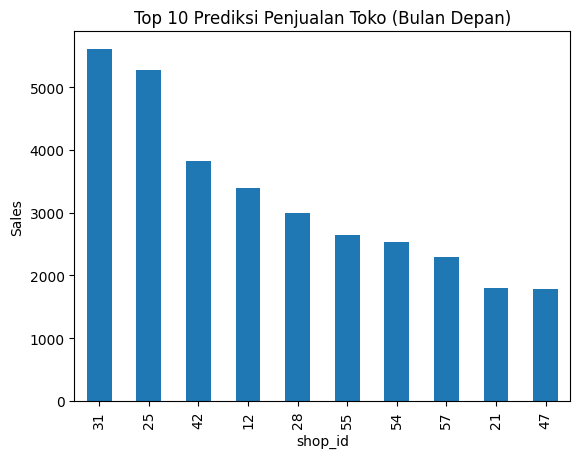

In [ ]:
plt.figure(figsize=(10,4))
pred_df.sort_values('predicted_sales', ascending=False)\
       .head(10)\
       .plot(kind='bar', x='shop_id', y='predicted_sales', legend=False)

plt.title("Top 10 Prediksi Penjualan Toko (Bulan Depan)")
plt.ylabel("Sales")
plt.show()


In [ ]:
# Total penjualan bulan terakhir (aktual)
last_month = monthly_sales['year_month'].max()

actual_last_month = (
    monthly_sales[monthly_sales['year_month'] == last_month]['sales']
    .sum()
)

print("Total penjualan bulan terakhir (aktual):", actual_last_month)
print("Total prediksi bulan depan:", round(total_predicted_sales, 2))


Total penjualan bulan terakhir (aktual): 71056.0
Total prediksi bulan depan: 76106.62
